In [141]:
suppressWarnings(suppressPackageStartupMessages({
  library(dplyr)
  library(readxl)
  library(anthro)
  library(anthroplus)
  library(writexl)
  library(ggplot2)
  library(tidyverse)
  library(gridExtra)
  library(zscorer)
  library(scales)
  library(ggthemes)
  library(tidyr)
  library(forcats)
  library(nlme)
  library(emmeans)
  library(patchwork)
  library(psych)
  library(nlme)
  library(tibble)
  library(lme4)
  library(lmerTest) 
}))

In [143]:
df_questionnaire <- suppressWarnings(read_excel("../data/clean/clean.xlsx"))
df_questionnaire$screening_date <- as.Date(as.numeric(df_questionnaire$screening_date), origin = "1899-12-30")
dg   <- suppressWarnings(lubridate::dmy(df_questionnaire$dob_guardian))
num  <- suppressWarnings(as.numeric(df_questionnaire$dob_guardian))
mask <- is.na(dg) & !is.na(num)
dg[mask] <- as.Date(num[mask], origin = "1899-12-30")
df_questionnaire$dob_guardian <- dg

In [144]:
head(df_questionnaire)

record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,⋯,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
<dbl>,<chr>,<chr>,<date>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>
1,GH1,GH001,4679305-04-13,2315646-01-25,27,Female,Mother,Neutral/ I don't know,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
2,GH2,GH001,4679305-04-13,NA,NA,Female,Mother,Strongly Agree,Disagree,⋯,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NA,Ghana
3,GH3,GH001,4679305-04-13,1880148-01-04,32,Female,Mother,Neutral/ I don't know,Disagree,⋯,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
4,GH4,GH001,4679305-04-13,NA,26,Female,Mother,Strongly Agree,Agree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
5,GH5,GH001,4679541-11-02,1989199-12-10,31,Female,Mother,Agree,Neutral/ I don't know,⋯,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NA,Ghana
6,GH6,GH001,4679541-11-02,NA,36,Female,Mother,Neutral/ I don't know,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana


In [145]:
data.frame(idx = seq_along(names(df_questionnaire)), col = names(df_questionnaire))

idx,col
<int>,<chr>
1,record_id
2,participant_id
3,facility_id
4,screening_date
5,dob_guardian
6,age
7,sex_guardian
8,guardian_relationship
9,detection_at_birth


In [146]:
# Which columns are Likert?
likert_cols <- intersect(c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
), names(df_questionnaire))

normalize_likert <- function(v) {
  canon <- c(
    "strongly disagree" = "Strongly Disagree",
    "disagree"          = "Disagree",
    "neutral"           = "Neutral",
    "agree"             = "Agree",
    "strongly agree"    = "Strongly Agree"
  )
  y <- trimws(tolower(as.character(v)))
  z <- unname(canon[y])                 # unmatched -> NA
  factor(z, levels = unname(canon), ordered = TRUE)
}

df_questionnaire[likert_cols] <- lapply(df_questionnaire[likert_cols], normalize_likert)

In [147]:
dplyr::count(df_questionnaire, country, sort = TRUE)

country,n
<chr>,<int>
Nigeria,2507
Zimbabwe/Zambia,1100
Mali,1011
Tanzania,1000
Ghana,999
Uganda,980


In [148]:
head(df_questionnaire)

record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,⋯,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
<dbl>,<chr>,<chr>,<date>,<date>,<dbl>,<chr>,<chr>,<ord>,<ord>,⋯,<ord>,<ord>,<ord>,<ord>,<ord>,<chr>,<chr>,<chr>,<lgl>,<chr>
1,GH1,GH001,4679305-04-13,2315646-01-25,27,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
2,GH2,GH001,4679305-04-13,NA,NA,Female,Mother,Strongly Agree,Disagree,⋯,NA,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NA,Ghana
3,GH3,GH001,4679305-04-13,1880148-01-04,32,Female,Mother,NA,Disagree,⋯,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
4,GH4,GH001,4679305-04-13,NA,26,Female,Mother,Strongly Agree,Agree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
5,GH5,GH001,4679541-11-02,1989199-12-10,31,Female,Mother,Agree,NA,⋯,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NA,Ghana
6,GH6,GH001,4679541-11-02,NA,36,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana


## EDA

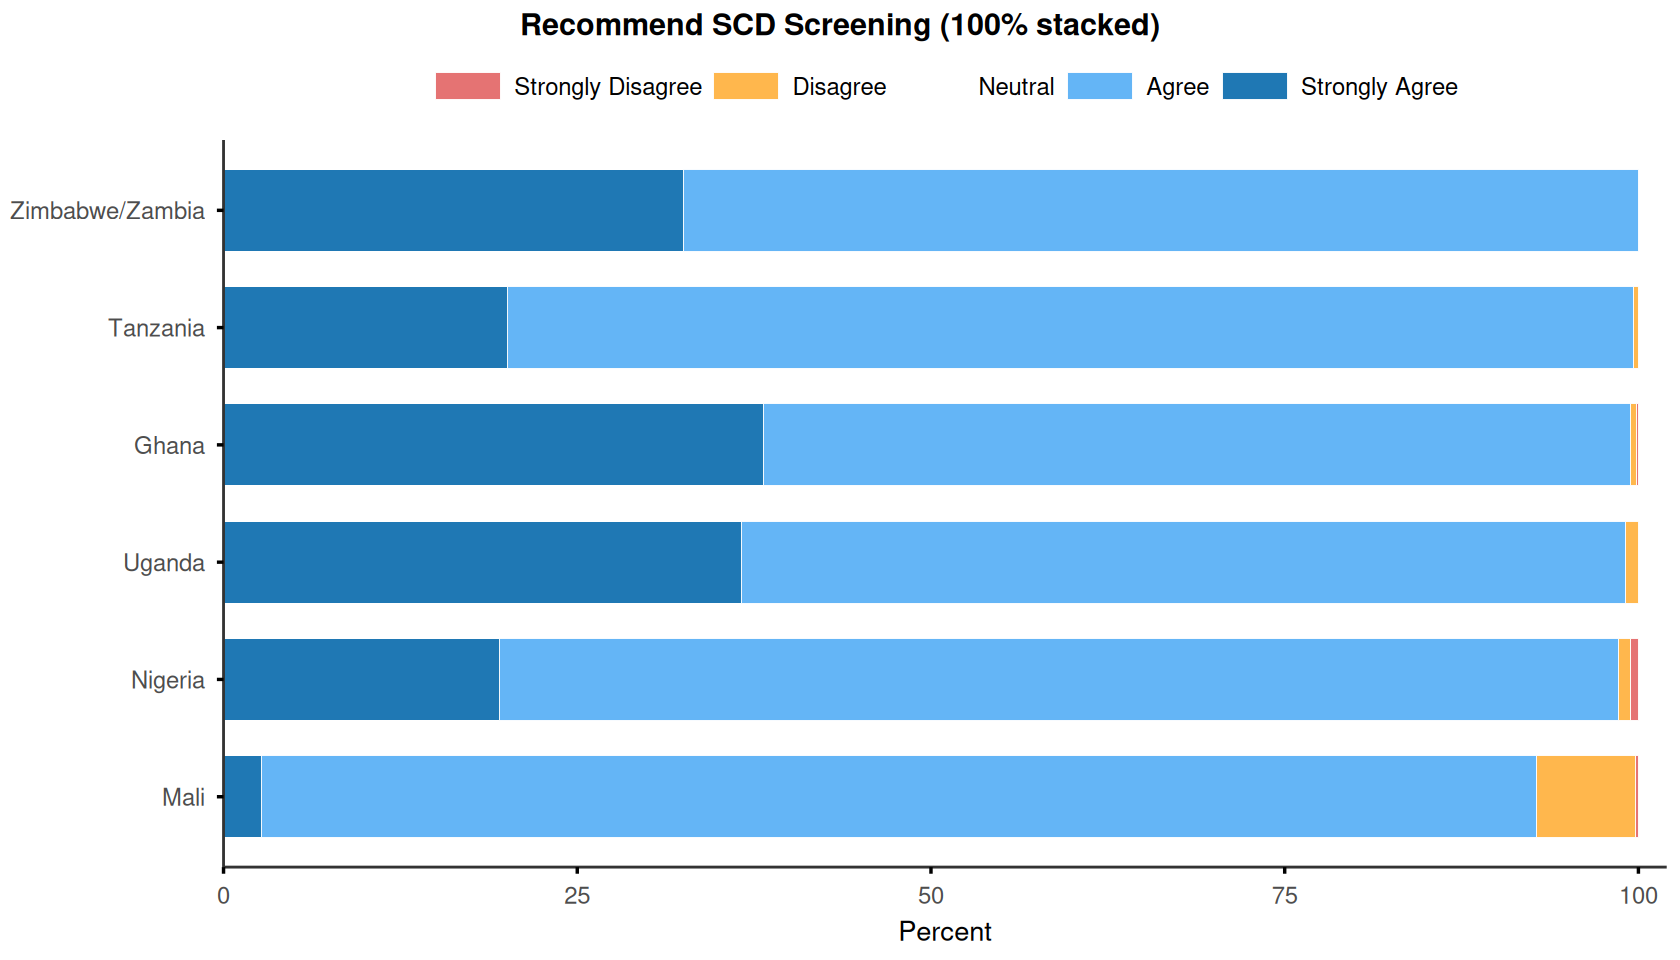

In [149]:
ow <- options(repr.plot.width = 14, repr.plot.height = 8)

item <- "screening_recommendation"
lvls <- c("Strongly Disagree","Disagree","Neutral","Agree","Strongly Agree")
pal  <- c("#e57373","#ffb74d","#d9d9d9","#64b5f6","#1f78b4")  

order_cty <- df_questionnaire %>%
  filter(!is.na(.data[[item]])) %>%
  mutate(agree = .data[[item]] %in% c("Agree","Strongly Agree")) %>%
  group_by(country) %>% summarise(pct_agree = mean(agree)*100, .groups="drop") %>%
  arrange(pct_agree) %>% pull(country)

df_item <- df_questionnaire %>%
  filter(!is.na(.data[[item]])) %>%
  count(country, !!rlang::sym(item)) %>%
  group_by(country) %>% mutate(pct = 100 * n / sum(n)) %>% ungroup() %>%
  mutate(country = factor(country, levels = order_cty),
         !!item := factor(.data[[item]], levels = lvls, ordered = TRUE))

ggplot(df_item, aes(x = country, y = pct, fill = .data[[item]])) +
  geom_col(width = 0.7, color = "white", linewidth = 0.2) +
  coord_flip() +
  scale_fill_manual(values = pal, drop = FALSE, guide = guide_legend(title = NULL)) +
  scale_y_continuous(expand = expansion(mult = c(0, .02))) +
  labs(title = "Recommend SCD Screening (100% stacked)", x = NULL, y = "Percent") +
  theme_minimal(base_size = 16) +  
  theme(
    panel.grid = element_blank(),              
    axis.ticks = element_line(),               
    axis.title.x = element_text(size = 16, margin = margin(t = 8)),
    axis.title.y = element_text(size = 16, margin = margin(r = 8)),
    axis.text = element_text(size = 14),
    axis.line.x = element_line(color = "grey20", linewidth = 0.6),  # x axis line
    axis.line.y = element_line(color = "grey20", linewidth = 0.6),  # y axis line
    plot.title.position = "plot",
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18, margin = margin(b = 10)), # centered
    legend.position = "top",
    legend.text = element_text(size = 14),
    legend.key.height = unit(6, "mm"),
    legend.key.width  = unit(14, "mm")
  )

ggsave("figures/eda/recommend_screening_stacked.png", width = 11, height = 5, dpi = 300)

In [150]:
likert_cols <- intersect(c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
), names(df_questionnaire))

lvls <- c("Strongly Disagree","Disagree","Neutral","Agree","Strongly Agree")
pal  <- c("#e57373","#ffb74d","#d9d9d9","#64b5f6","#1f78b4")

dir.create("figures/eda", recursive = TRUE, showWarnings = FALSE)

for (item in likert_cols) {
  order_cty <- df_questionnaire |>
    dplyr::filter(!is.na(.data[[item]])) |>
    dplyr::mutate(agree = .data[[item]] %in% c("Agree","Strongly Agree")) |>
    dplyr::group_by(country) |>
    dplyr::summarise(pct_agree = mean(agree) * 100, .groups = "drop") |>
    dplyr::arrange(pct_agree) |>
    dplyr::pull(country)

  df_item <- df_questionnaire |>
    dplyr::filter(!is.na(.data[[item]])) |>
    dplyr::count(country, resp = .data[[item]]) |>
    dplyr::group_by(country) |>
    dplyr::mutate(pct = 100 * n / sum(n)) |>
    dplyr::ungroup() |>
    dplyr::mutate(
      country = factor(country, levels = order_cty),
      resp = factor(resp, levels = lvls, ordered = TRUE)
    )

  p <- ggplot2::ggplot(df_item, ggplot2::aes(x = country, y = pct, fill = resp)) +
    ggplot2::geom_col(width = 0.7, color = "white", linewidth = 0.2) +
    ggplot2::coord_flip() +
    ggplot2::scale_fill_manual(values = pal, drop = FALSE, guide = ggplot2::guide_legend(title = NULL)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, .02))) +
    ggplot2::labs(title = gsub("_", " ", tools::toTitleCase(item)), x = NULL, y = "Percent") +
    ggplot2::theme_minimal(base_size = 16) +
    ggplot2::theme(
      panel.grid = ggplot2::element_blank(),
      axis.ticks = ggplot2::element_line(),
      axis.title.x = ggplot2::element_text(size = 16, margin = ggplot2::margin(t = 8)),
      axis.title.y = ggplot2::element_text(size = 16, margin = ggplot2::margin(r = 8)),
      axis.text = ggplot2::element_text(size = 14),
      axis.line.x = ggplot2::element_line(color = "grey20", linewidth = 0.6),
      axis.line.y = ggplot2::element_line(color = "grey20", linewidth = 0.6),
      plot.title = ggplot2::element_text(hjust = 0.5, face = "bold", size = 18, margin = ggplot2::margin(b = 10)),
      legend.position = "top",
      legend.text = ggplot2::element_text(size = 14),
      legend.key.height = grid::unit(6, "mm"),
      legend.key.width  = grid::unit(14, "mm")
    )

  ggplot2::ggsave(file.path("figures/eda", paste0(item, "_stacked.png")),
                  plot = p, width = 14, height = 8, dpi = 300)
}

invisible(NULL)

## Preparation

In [151]:
suppressWarnings(suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(psych)
}))

LIKERT_COLS <- c("Strongly Disagree","Disagree","Neutral","Agree","Strongly Agree")
LIKERT_ITEMS <- c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
)

df_questionnaire <- df_questionnaire %>%
  mutate(across(all_of(LIKERT_ITEMS),
                ~ factor(.x, levels = LIKERT_COLS, ordered = TRUE)))

In [152]:
head(df_questionnaire)

record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,⋯,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
<dbl>,<chr>,<chr>,<date>,<date>,<dbl>,<chr>,<chr>,<ord>,<ord>,⋯,<ord>,<ord>,<ord>,<ord>,<ord>,<chr>,<chr>,<chr>,<lgl>,<chr>
1,GH1,GH001,4679305-04-13,2315646-01-25,27,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
2,GH2,GH001,4679305-04-13,NA,NA,Female,Mother,Strongly Agree,Disagree,⋯,NA,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NA,Ghana
3,GH3,GH001,4679305-04-13,1880148-01-04,32,Female,Mother,NA,Disagree,⋯,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
4,GH4,GH001,4679305-04-13,NA,26,Female,Mother,Strongly Agree,Agree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana
5,GH5,GH001,4679541-11-02,1989199-12-10,31,Female,Mother,Agree,NA,⋯,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NA,Ghana
6,GH6,GH001,4679541-11-02,NA,36,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana


In [153]:
LIKERT_ITEMS <- c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
)
LIKERT_COLS <- c("Strongly Disagree","Disagree","Neutral","Agree","Strongly Agree")

df_questionnaire <- df_questionnaire %>%
  mutate(across(all_of(LIKERT_ITEMS),
                ~ factor(.x, levels = LIKERT_COLS, ordered = TRUE)))

sapply(df_questionnaire[LIKERT_ITEMS], levels)

detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment
Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree
Disagree,Disagree,Disagree,Disagree,Disagree,Disagree,Disagree,Disagree,Disagree,Disagree
Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral
Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree
Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree


## Analysis

In [154]:
LIKERT_ITEMS <- c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
)

likert_to_int <- function(x) {
  s <- tolower(trimws(as.character(x)))
  s[s %in% c("1","strongly disagree","sd")] <- "1"
  s[s %in% c("2","disagree","d")]           <- "2"
  s[s %in% c("3","neutral","neither","neut")] <- "3"
  s[s %in% c("4","agree","a")]              <- "4"
  s[s %in% c("5","strongly agree","sa")]    <- "5"
  out <- suppressWarnings(as.integer(s))
  out[!(out %in% 1:5)] <- NA_integer_
  out
}

Xint <- df_questionnaire %>%
  mutate(across(all_of(LIKERT_ITEMS), likert_to_int)) %>%
  select(all_of(LIKERT_ITEMS))

keep_items <- vapply(Xint, function(v) length(unique(na.omit(v))) >= 2, logical(1))
if (!all(keep_items)) message("Dropping items with <2 categories: ",
                              paste(names(keep_items)[!keep_items], collapse = ", "))
Xint <- Xint[keep_items]
Xint <- Xint[rowSums(!is.na(Xint)) > 0, , drop = FALSE]

if (ncol(Xint) < 2L) stop("Not enough usable Likert items left for factor analysis.")

pc   <- suppressWarnings(psych::polychoric(as.matrix(Xint))$rho)
kmo  <- psych::KMO(pc)
Nobs <- nrow(stats::na.omit(Xint))
bart <- psych::cortest.bartlett(pc, n = Nobs)
eigs <- eigen(pc)$values

In [155]:
kmo$MSA    

[1] 0.9243247

In [156]:
kmo$MSAi   

detection_at_birth              scd_longevity 
                 0.8782175                  0.8311450 
early_detection_importance      need_immediate_result 
                 0.9453966                  0.9467583 
          enough_poct_info          poct_result_speed 
                 0.8996527                  0.9499921 
  screening_recommendation        poct_recommendation 
                 0.9337673                  0.9217625 
        dbs_for_validation           proper_treatment 
                 0.9259773                  0.9316963

In [157]:
bart       

$chisq
[1] 25716.31

$p.value
[1] 0

$df
[1] 45

In [158]:
eigs       

[1] 5.9436144 1.1883564 0.7154660 0.4160011 0.3951156 0.3654930 0.2931036
 [8] 0.2474258 0.2274954 0.2079287

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 


[1] 4

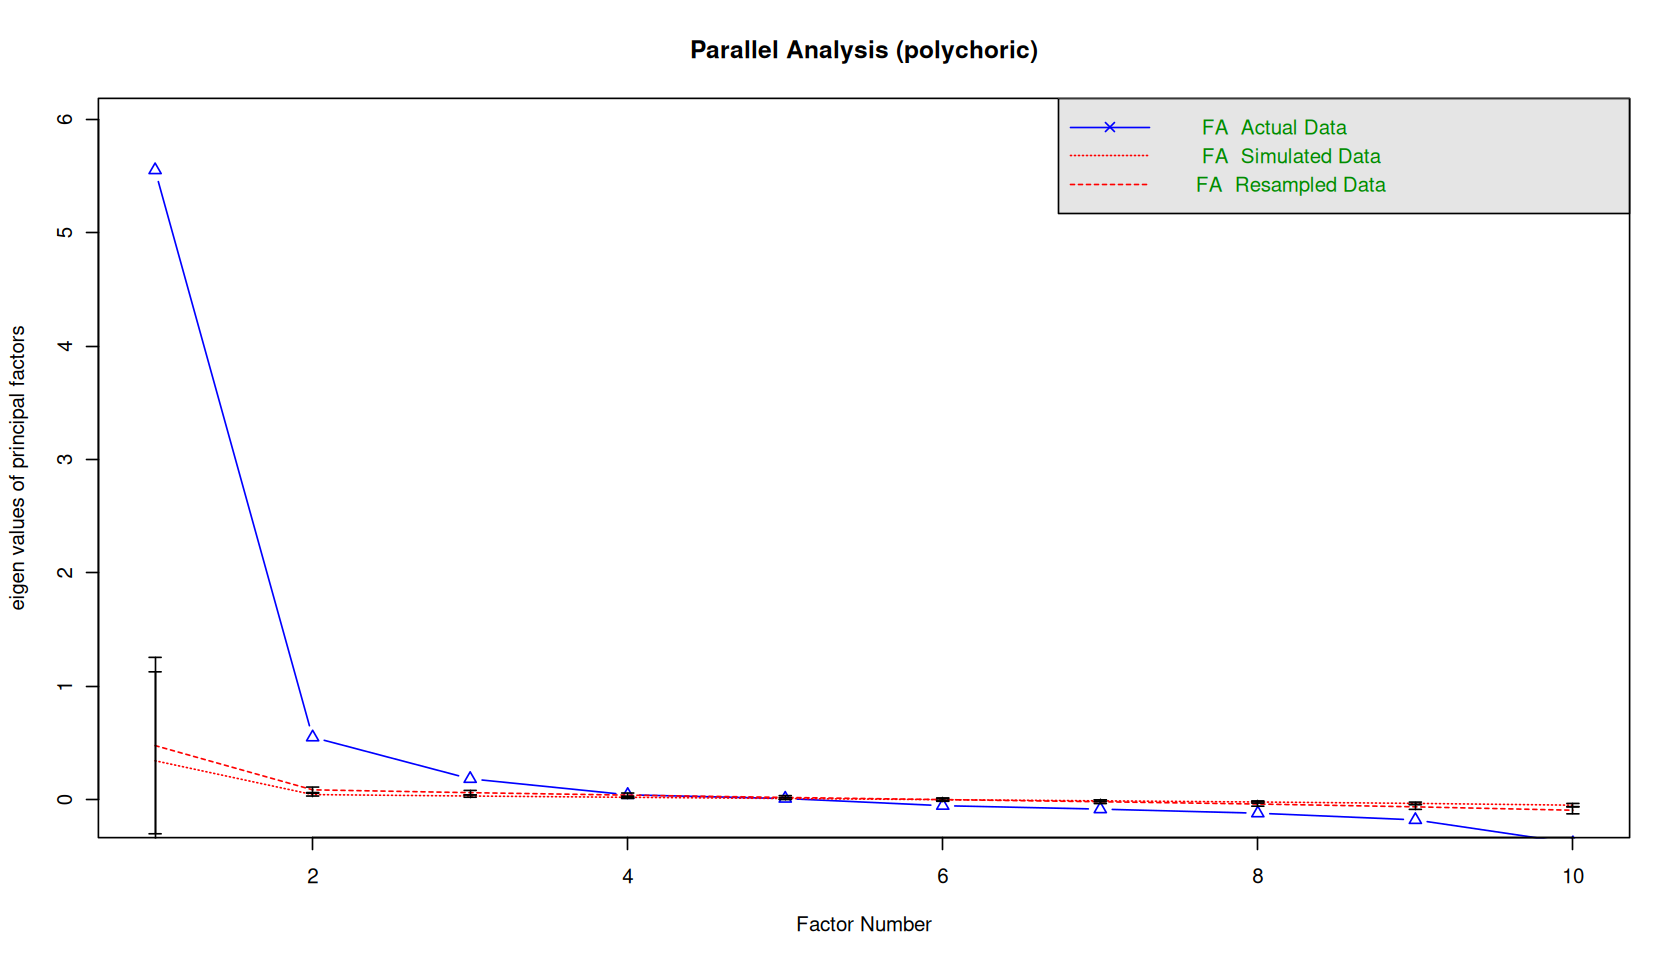

In [159]:
LIKERT_ITEMS <- c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
)
likert_to_int <- function(x){
  s <- tolower(trimws(as.character(x)))
  s[s %in% c("1","strongly disagree","sd")] <- "1"
  s[s %in% c("2","disagree","d")]           <- "2"
  s[s %in% c("3","neutral","neither","neut")] <- "3"
  s[s %in% c("4","agree","a")]              <- "4"
  s[s %in% c("5","strongly agree","sa")]    <- "5"
  out <- suppressWarnings(as.integer(s))
  out[!(out %in% 1:5)] <- NA_integer_
  out
}
Xint <- df_questionnaire |>
  dplyr::mutate(dplyr::across(dplyr::all_of(LIKERT_ITEMS), likert_to_int)) |>
  dplyr::select(dplyr::all_of(LIKERT_ITEMS))
Xint <- Xint[rowSums(!is.na(Xint)) > 0, , drop = FALSE]

pa <- fa.parallel(Xint, fa = "fa", fm = "ml", cor = "poly",
                  n.iter = 200, error.bars = TRUE,
                  main = "Parallel Analysis (polychoric)")

k_pa <- tryCatch({
  idx <- which(pa$fa.values > pa$fa.sim)
  if (length(idx) == 0) 1L else max(idx)
}, error = function(e) 1L)

k_pa

In [160]:
suppressWarnings(suppressPackageStartupMessages(library(psych)))

k <- 4L

efa4 <- fa(Xint, nfactors = k, fm = "ml", rotate = "oblimin",
           cor = "poly")   

print(efa4$loadings, cutoff = 0.30, digits = 3)
efa4$TLI
efa4$RMSEA
round(efa4$Phi, 3)   

L <- as.matrix(efa4$loadings)
items_by_factor <- lapply(seq_len(k), function(j) rownames(L)[abs(L[, j]) >= 0.30])
items_by_factor


Loadings:
                           ML2    ML3    ML1    ML4   
detection_at_birth                 0.785              
scd_longevity                      0.780              
early_detection_importance  0.382  0.332              
need_immediate_result                     1.006       
enough_poct_info                                 0.857
poct_result_speed           0.448                     
screening_recommendation    0.774                     
poct_recommendation         0.918                     
dbs_for_validation          0.566                0.340
proper_treatment            0.888                     

                 ML2   ML3   ML1   ML4
SS loadings    2.907 1.366 1.104 0.898
Proportion Var 0.291 0.137 0.110 0.090
Cumulative Var 0.291 0.427 0.538 0.627


[1] 0.9767072

RMSEA      lower      upper confidence 
0.05955951 0.05372953 0.06560455 0.90000000

,ML2,ML3,ML1,ML4
ML2,1.000,0.484,0.731,0.572
ML3,0.484,1.000,0.562,0.377
ML1,0.731,0.562,1.000,0.483
ML4,0.572,0.377,0.483,1.000


[[1]]
[1] "early_detection_importance" "poct_result_speed"         
[3] "screening_recommendation"   "poct_recommendation"       
[5] "dbs_for_validation"         "proper_treatment"          

[[2]]
[1] "detection_at_birth"         "scd_longevity"             
[3] "early_detection_importance"

[[3]]
[1] "need_immediate_result"

[[4]]
[1] "enough_poct_info"   "dbs_for_validation"

In [161]:
library(psych)

efa3 <- fa(Xint, nfactors = 3, fm = "ml", rotate = "oblimin", cor = "poly")
efa4 <- fa(Xint, nfactors = 4, fm = "ml", rotate = "oblimin", cor = "poly")

data.frame(
  k    = c(3, 4),
  TLI  = c(efa3$TLI,  efa4$TLI),
  RMSEA= c(efa3$RMSEA[1], efa4$RMSEA[1])
)

print(fa.sort(efa3)$loadings, cutoff = 0.30, digits = 3)

k,TLI,RMSEA
<dbl>,<dbl>,<dbl>
3,0.9627457,0.07532675
4,0.9767072,0.05955951



Loadings:
                           ML1    ML2    ML3   
poct_recommendation         0.944              
proper_treatment            0.875              
screening_recommendation    0.860              
dbs_for_validation          0.615         0.383
need_immediate_result       0.592              
poct_result_speed           0.571              
early_detection_importance  0.495  0.364       
scd_longevity                      0.783       
detection_at_birth                 0.753       
enough_poct_info                          0.799

                 ML1   ML2   ML3
SS loadings    3.707 1.419 0.850
Proportion Var 0.371 0.142 0.085
Cumulative Var 0.371 0.513 0.598


In [162]:
LIKERT_ITEMS <- c(
  "detection_at_birth","scd_longevity","early_detection_importance",
  "need_immediate_result","enough_poct_info","poct_result_speed",
  "screening_recommendation","poct_recommendation","dbs_for_validation","proper_treatment"
)
likert_to_int <- function(x){
  s <- tolower(trimws(as.character(x)))
  s[s %in% c("1","strongly disagree","sd")] <- "1"
  s[s %in% c("2","disagree","d")]           <- "2"
  s[s %in% c("3","neutral","neither","neut")] <- "3"
  s[s %in% c("4","agree","a")]              <- "4"
  s[s %in% c("5","strongly agree","sa")]    <- "5"
  out <- suppressWarnings(as.integer(s)); out[!(out %in% 1:5)] <- NA_integer_; out
}
Xint <- df_questionnaire |>
  mutate(across(all_of(LIKERT_ITEMS), likert_to_int)) |>
  select(all_of(LIKERT_ITEMS))

# Item sets from EFA (k = 3)
F1_items <- c("screening_recommendation","poct_recommendation",
              "proper_treatment","need_immediate_result","early_detection_importance")
F2_items <- c("detection_at_birth","scd_longevity")
F3_items <- c("dbs_for_validation","enough_poct_info","poct_result_speed")

F1_readiness <- rowMeans(Xint[, F1_items, drop = FALSE], na.rm = TRUE)
F2_knowledge <- rowMeans(Xint[, F2_items, drop = FALSE], na.rm = TRUE)
F3_poct      <- rowMeans(Xint[, F3_items, drop = FALSE], na.rm = TRUE)

df_questionnaire$F1_readiness <- F1_readiness
df_questionnaire$F2_knowledge <- F2_knowledge
df_questionnaire$F3_poct      <- F3_poct

alpha_F1 <- psych::alpha(Xint[, F1_items])
alpha_F3 <- psych::alpha(Xint[, F3_items])

r12 <- suppressWarnings(cor(Xint[, F2_items[1]], Xint[, F2_items[2]],
                            use = "pairwise.complete.obs"))
sb_F2 <- 2 * r12 / (1 + r12)

alpha_F1$total$raw_alpha  
alpha_F3$total$raw_alpha  
sb_F2                      

summary(df_questionnaire[, c("F1_readiness","F2_knowledge","F3_poct")])

[1] 0.8119613

[1] 0.6178221

,scd_longevity
detection_at_birth,0.655771


  F1_readiness    F2_knowledge      F3_poct     
 Min.   :1.000   Min.   :1.000   Min.   :1.000  
 1st Qu.:4.000   1st Qu.:4.000   1st Qu.:4.000  
 Median :4.000   Median :4.000   Median :4.000  
 Mean   :4.169   Mean   :3.848   Mean   :4.081  
 3rd Qu.:4.400   3rd Qu.:4.000   3rd Qu.:4.333  
 Max.   :5.000   Max.   :5.000   Max.   :5.000  
 NA's   :528     NA's   :1118    NA's   :767    

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”
Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


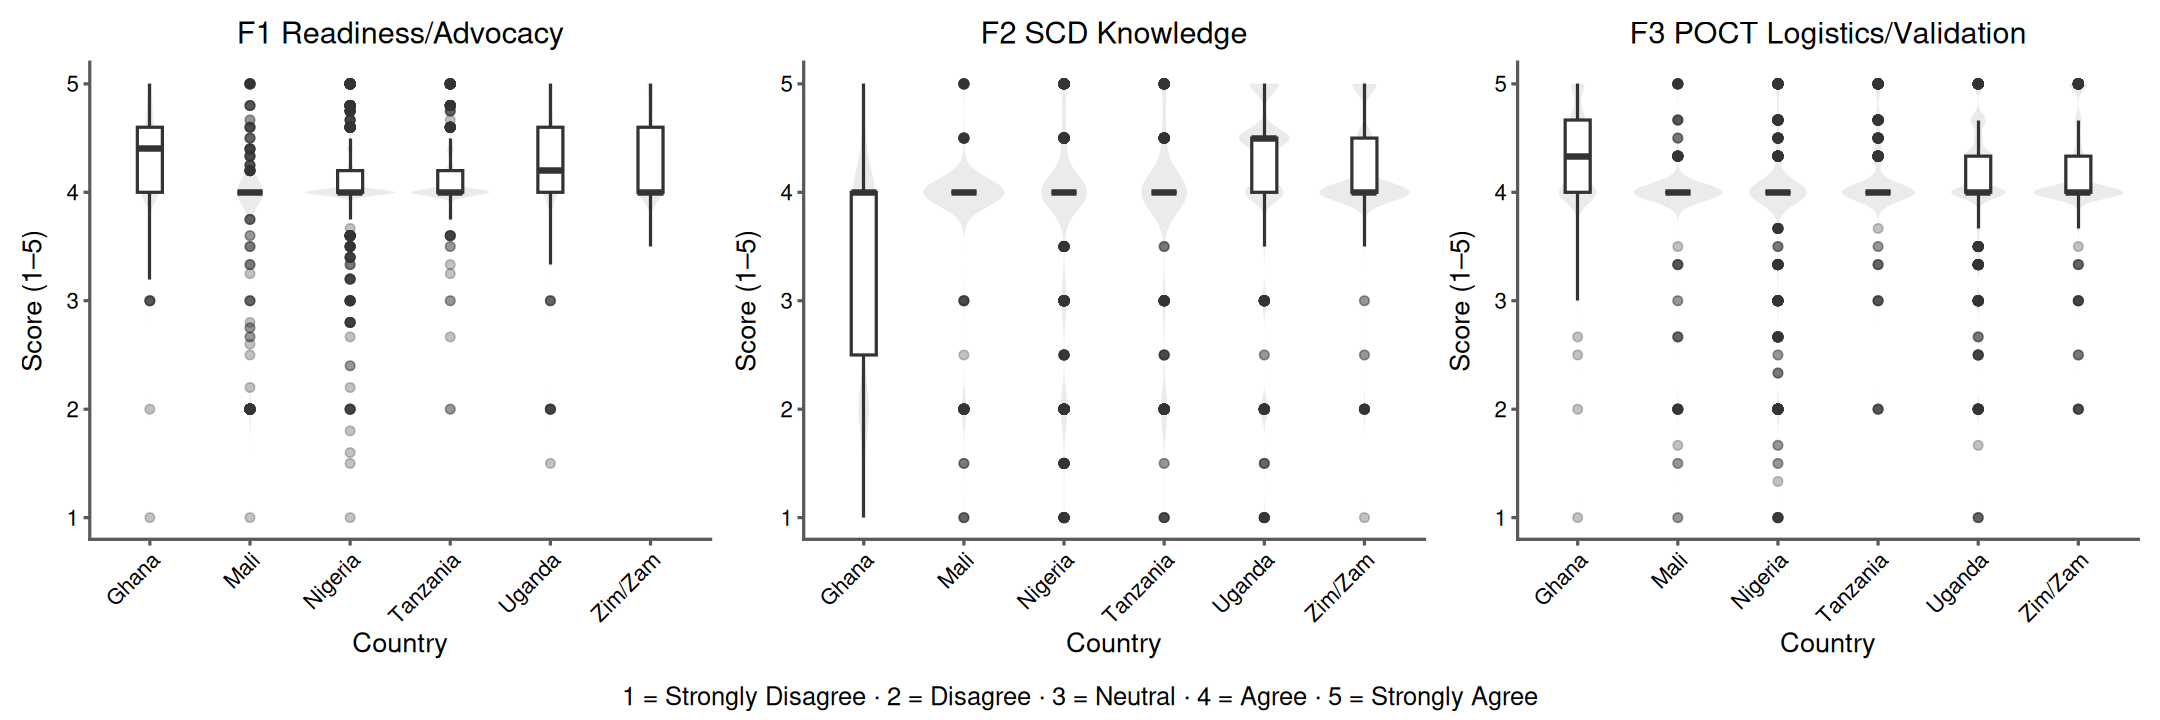

In [163]:
library(ggplot2)
library(dplyr)
library(patchwork)

df_questionnaire <- df_questionnaire %>%
  mutate(
    country = factor(
      ifelse(
        tolower(as.character(country)) == "zimbabwe/zambia",
        "Zim/Zam",
        as.character(country)
      )
    )
  )

dfp <- df_questionnaire %>%
  filter(!is.na(country)) %>%
  mutate(country = factor(country))

ow <- options(repr.plot.width = 18, repr.plot.height = 6)

base_style <- list(
  theme_classic(base_size = 15),
  theme(
    plot.title   = element_text(hjust = 0.5, size = 18),
    axis.title   = element_text(size = 16),
#     axis.title.x = element_text(margin = margin(t = 12)),
    axis.text.x  = element_text(size = 13, angle = 45, hjust = 1, vjust = 1),
    axis.title.y = element_text(margin = margin(r = 12)),
    axis.text    = element_text(size = 13),
    axis.ticks   = element_line(color = "grey35"),
    axis.line    = element_line(color = "grey35")
  )
)

p1 <- ggplot(dfp, aes(country, F1_readiness)) +
  geom_violin(fill = "grey92", color = NA, trim = TRUE, na.rm = TRUE) +
  geom_boxplot(width = 0.25, outlier.alpha = 0.3, na.rm = TRUE) +
  labs(title = "F1 Readiness/Advocacy", x = "Country", y = "Score (1–5)") +
  base_style

p2 <- ggplot(dfp, aes(country, F2_knowledge)) +
  geom_violin(fill = "grey92", color = NA, trim = TRUE, na.rm = TRUE) +
  geom_boxplot(width = 0.25, outlier.alpha = 0.3, na.rm = TRUE) +
  labs(title = "F2 SCD Knowledge", x = "Country", y = "Score (1–5)") +
  base_style

p3 <- ggplot(dfp, aes(country, F3_poct)) +
  geom_violin(fill = "grey92", color = NA, trim = TRUE, na.rm = TRUE) +
  geom_boxplot(width = 0.25, outlier.alpha = 0.3, na.rm = TRUE) +
  labs(title = "F3 POCT Logistics/Validation", x = "Country", y = "Score (1–5)") +
  base_style

key_text <- "1 = Strongly Disagree · 2 = Disagree · 3 = Neutral · 4 = Agree · 5 = Strongly Agree"

final_plot <- (p1 | p2 | p3) +
  plot_layout(ncol = 3, widths = c(1, 1, 1)) +
  plot_annotation(
    caption = key_text,
    theme = theme(
      plot.caption.position = "plot",
      plot.caption = element_text(
        hjust = 0.5,
        size = 15,
        margin = margin(t = 10)
      )
    )
  )

out_dir  <- "figures/analysis"
out_base <- file.path(out_dir, "factor_scores_violin_box")

dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

ggsave(
  filename = paste0(out_base, ".png"),
  plot     = final_plot,
  width    = 16,
  height   = 6,
  units    = "in",
  dpi      = 600,
  bg       = "white",
  type     = "cairo"
)

final_plot

options(ow)

In [164]:
df_kw <- df_questionnaire %>%
  filter(!is.na(country)) %>%
  mutate(country = factor(country))

In [165]:
head(df_questionnaire)

record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,⋯,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country,F1_readiness,F2_knowledge,F3_poct
<dbl>,<chr>,<chr>,<date>,<date>,<dbl>,<chr>,<chr>,<ord>,<ord>,⋯,<ord>,<ord>,<chr>,<chr>,<chr>,<lgl>,<fct>,<dbl>,<dbl>,<dbl>
1,GH1,GH001,4679305-04-13,2315646-01-25,27,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana,4.8,2.0,4.333333
2,GH2,GH001,4679305-04-13,NA,NA,Female,Mother,Strongly Agree,Disagree,⋯,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NA,Ghana,4.8,3.5,5.000000
3,GH3,GH001,4679305-04-13,1880148-01-04,32,Female,Mother,NA,Disagree,⋯,Agree,Strongly Agree,No,Yes,Yes,NA,Ghana,4.8,2.0,4.666667
4,GH4,GH001,4679305-04-13,NA,26,Female,Mother,Strongly Agree,Agree,⋯,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana,4.4,4.5,4.666667
5,GH5,GH001,4679541-11-02,1989199-12-10,31,Female,Mother,Agree,NA,⋯,Agree,Agree,No,Yes,Yes,NA,Ghana,4.0,4.0,4.000000
6,GH6,GH001,4679541-11-02,NA,36,Female,Mother,NA,Disagree,⋯,Strongly Agree,Strongly Agree,No,Yes,Yes,NA,Ghana,5.0,2.0,4.666667


In [166]:
dfm_F1 <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    country = factor(country),
    F1_readiness = suppressWarnings(as.numeric(F1_readiness))
  ) %>%
  select(country, F1_readiness) %>%
  filter(!is.na(country), !is.na(F1_readiness))

In [167]:
dfm_F1 <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    F1 = suppressWarnings(as.numeric(F1_readiness))
  ) %>%
  filter(!is.na(country), is.finite(F1), F1 >= 1, F1 <= 5) %>%
  mutate(country = factor(country))

fit_F1_country_lme <- lme(
  F1 ~ 1,
  random = ~1 | country,
  data   = dfm_F1,
  method = "REML",
  na.action = na.omit,
  control = lmeControl(msMaxIter = 100, msMaxEval = 100)
)

print(summary(fit_F1_country_lme))

vc <- VarCorr(fit_F1_country_lme)

int_row <- which(rownames(vc) == "(Intercept)")[1]
sd_cty  <- as.numeric(vc[int_row, "StdDev"])
sd_res  <- as.numeric(vc["Residual", "StdDev"])

v_cty <- sd_cty^2
v_res <- sd_res^2
ICC   <- v_cty / (v_cty + v_res)

gm  <- fixed.effects(fit_F1_country_lme)[1]
se  <- sqrt(vcov(fit_F1_country_lme)[1, 1])
gm_l <- gm - 1.96 * se
gm_u <- gm + 1.96 * se

cat(sprintf(
  "\n== F1 (Readiness/Advocacy): Consolidated ==\nObservations: %d\nGrand mean (95%% CI): %.3f [%.3f, %.3f]\nVar(country): %.4f  Var(resid): %.4f\nICC(country): %.3f\n",
  nrow(dfm_F1), gm, gm_l, gm_u, v_cty, v_res, ICC
))

Linear mixed-effects model fit by REML
  Data: dfm_F1 
       AIC      BIC    logLik
  7296.935 7317.525 -3645.467

Random effects:
 Formula: ~1 | country
        (Intercept)  Residual
StdDev:   0.1754144 0.4042667

Fixed effects:  F1 ~ 1 
               Value  Std.Error   DF  t-value p-value
(Intercept) 4.181498 0.07179197 7063 58.24465       0

Standardized Within-Group Residuals:
       Min         Q1        Med         Q3        Max 
-8.2561664 -0.3581283 -0.2881857  0.3017481  2.7753626 

Number of Observations: 7069
Number of Groups: 6 

== F1 (Readiness/Advocacy): Consolidated ==
Observations: 7069
Grand mean (95% CI): 4.181 [4.041, 4.322]
Var(country): 0.0308  Var(resid): 0.1634
ICC(country): 0.158


In [168]:
suppressWarnings(suppressPackageStartupMessages({
  library(dplyr)
  library(nlme)
  library(tibble)
}))

# Prep (harmonise country label; keeping valid scores only) ---
dfm_F1_fac <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    facility = as.character(facility_id),
    F1 = suppressWarnings(as.numeric(F1_readiness))
  ) %>%
  filter(!is.na(country), !is.na(facility), is.finite(F1), F1 >= 1, F1 <= 5) %>%
  mutate(country = factor(country),
         facility = factor(facility))

# Random-intercept model: facility nested within country ---
fit_F1_cf <- lme(
  F1 ~ 1,
  random = ~ 1 | country/facility,
  data   = dfm_F1_fac,
  method = "REML",
  na.action = na.omit,
  control = lmeControl(msMaxIter = 100, msMaxEval = 100)
)

print(summary(fit_F1_cf))

# Variance components + ICCs ---
vc <- VarCorr(fit_F1_cf)

# In nlme::VarCorr the two '(Intercept)' rows correspond to country then facility
int_rows <- which(rownames(vc) == "(Intercept)")
sd_cty <- as.numeric(vc[int_rows[1], "StdDev"])
sd_fac <- as.numeric(vc[int_rows[2], "StdDev"])
sd_res <- as.numeric(vc["Residual",  "StdDev"])

v_cty <- sd_cty^2
v_fac <- sd_fac^2
v_res <- sd_res^2
v_tot <- v_cty + v_fac + v_res

ICC_country  <- v_cty / v_tot
ICC_facility <- v_fac / v_tot

# Pooled (grand) mean + 95% CI
gm  <- fixed.effects(fit_F1_cf)[1]
se  <- sqrt(vcov(fit_F1_cf)[1,1])
gm_l <- gm - 1.96 * se
gm_u <- gm + 1.96 * se

cat("\n== F1 (Readiness/Advocacy): country + facility (nested) ==\n")
cat(sprintf("Observations: %d  |  Countries: %d  |  Facilities: %d\n",
            nrow(dfm_F1_fac), nlevels(dfm_F1_fac$country), nlevels(dfm_F1_fac$facility)))
cat(sprintf("Grand mean (95%% CI): %.3f [%.3f, %.3f]\n", gm, gm_l, gm_u))
cat(sprintf("Var(country)=%.4f  Var(facility)=%.4f  Var(resid)=%.4f\n", v_cty, v_fac, v_res))
cat(sprintf("ICC_country=%.3f  ICC_facility=%.3f\n", ICC_country, ICC_facility))

# Shrunken country means
co_country <- coef(fit_F1_cf, level = 1)  # random-intercept BLUPs at country level
tab_country <- tibble(
  country = rownames(co_country),
  mean_F1 = as.numeric(co_country[,"(Intercept)"])
) %>% arrange(desc(mean_F1))

tab_country

Linear mixed-effects model fit by REML
  Data: dfm_F1_fac 
       AIC      BIC    logLik
  6503.361 6530.815 -3247.681

Random effects:
 Formula: ~1 | country
        (Intercept)
StdDev:   0.1343077

 Formula: ~1 | facility %in% country
        (Intercept) Residual
StdDev:   0.2117168 0.378024

Fixed effects:  F1 ~ 1 
              Value  Std.Error   DF t-value p-value
(Intercept) 4.14315 0.07306124 6944 56.7079       0

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-8.82997991 -0.38246376 -0.01364434  0.34376872  3.64551196 

Number of Observations: 7069
Number of Groups: 
              country facility %in% country 
                    6                   125 

== F1 (Readiness/Advocacy): country + facility (nested) ==
Observations: 7069  |  Countries: 6  |  Facilities: 124
Grand mean (95% CI): 4.143 [4.000, 4.286]
Var(country)=0.0180  Var(facility)=0.0448  Var(resid)=0.1429
ICC_country=0.088  ICC_facility=0.218


country,mean_F1
<chr>,<dbl>
Ghana,4.251333
Zim/Zam,4.237508
Uganda,4.155438
Tanzania,4.143560
Nigeria,4.088032
Mali,3.983027


In [169]:
dfm_F2 <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    facility = as.character(facility_id),
    F2 = suppressWarnings(as.numeric(F2_knowledge))
  ) %>%
  filter(!is.na(country), !is.na(facility), is.finite(F2), F2 >= 1, F2 <= 5) %>%
  mutate(country = factor(country),
         facility = factor(facility))

# Random-intercept model: facility nested in country ---
fit_F2_cf <- lme(
  F2 ~ 1,
  random = ~ 1 | country/facility,
  data   = dfm_F2,
  method = "REML",
  na.action = na.omit,
  control = lmeControl(msMaxIter = 100, msMaxEval = 100)
)

summary(fit_F2_cf)

vc <- VarCorr(fit_F2_cf)
int_rows <- which(rownames(vc) == "(Intercept)")
sd_cty <- as.numeric(vc[int_rows[1], "StdDev"])
sd_fac <- as.numeric(vc[int_rows[2], "StdDev"])
sd_res <- as.numeric(vc["Residual",  "StdDev"])

v_cty <- sd_cty^2
v_fac <- sd_fac^2
v_res <- sd_res^2
v_tot <- v_cty + v_fac + v_res

ICC_country  <- v_cty / v_tot
ICC_facility <- v_fac / v_tot

gm  <- fixed.effects(fit_F2_cf)[1]
se  <- sqrt(vcov(fit_F2_cf)[1,1])
gm_l <- gm - 1.96 * se
gm_u <- gm + 1.96 * se

cat("\n== F2 (SCD Knowledge): country + facility (nested) ==\n")
cat(sprintf("Observations: %d  |  Countries: %d  |  Facilities: %d\n",
            nrow(dfm_F2), nlevels(dfm_F2$country), nlevels(dfm_F2$facility)))
cat(sprintf("Grand mean (95%% CI): %.3f [%.3f, %.3f]\n", gm, gm_l, gm_u))
cat(sprintf("Var(country)=%.4f  Var(facility)=%.4f  Var(resid)=%.4f\n", v_cty, v_fac, v_res))
cat(sprintf("ICC_country=%.3f  ICC_facility=%.3f\n", ICC_country, ICC_facility))

co_country_F2 <- coef(fit_F2_cf, level = 1)
tab_country_F2 <- tibble(
  country = rownames(co_country_F2),
  mean_F2 = as.numeric(co_country_F2[, "(Intercept)"])
) %>% arrange(desc(mean_F2))

tab_country_F2

Linear mixed-effects model fit by REML
  Data: dfm_F2 
       AIC      BIC    logLik
  14537.67 14564.77 -7264.833

Random effects:
 Formula: ~1 | country
        (Intercept)
StdDev:   0.2903567

 Formula: ~1 | facility %in% country
        (Intercept)  Residual
StdDev:   0.5645174 0.7301851

Fixed effects:  F2 ~ 1 
               Value Std.Error   DF  t-value p-value
(Intercept) 3.683535 0.1681031 6366 21.91236       0

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-4.43247000 -0.24372730  0.01216674  0.43891323  2.46720801 

Number of Observations: 6478
Number of Groups: 
              country facility %in% country 
                    6                   112 


== F2 (SCD Knowledge): country + facility (nested) ==
Observations: 6478  |  Countries: 6  |  Facilities: 111
Grand mean (95% CI): 3.684 [3.354, 4.013]
Var(country)=0.0843  Var(facility)=0.3187  Var(resid)=0.5332
ICC_country=0.090  ICC_facility=0.340


country,mean_F2
<chr>,<dbl>
Zim/Zam,3.953446
Uganda,3.846707
Tanzania,3.711462
Mali,3.662385
Nigeria,3.504278
Ghana,3.422935


In [170]:
suppressWarnings(suppressPackageStartupMessages({
  library(dplyr)
  library(nlme)
  library(tibble)
}))

dfm_F3 <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    facility = as.character(facility_id),
    F3 = suppressWarnings(as.numeric(F3_poct))
  ) %>%
  filter(!is.na(country), !is.na(facility), is.finite(F3), F3 >= 1, F3 <= 5) %>%
  mutate(country = factor(country),
         facility = factor(facility))

# Random-intercept model: facility nested in country ---
fit_F3_cf <- lme(
  F3 ~ 1,
  random = ~ 1 | country/facility,
  data   = dfm_F3,
  method = "REML",
  na.action = na.omit,
  control = lmeControl(msMaxIter = 100, msMaxEval = 100)
)

summary(fit_F3_cf)

vc <- VarCorr(fit_F3_cf)
int_rows <- which(rownames(vc) == "(Intercept)")
sd_cty <- as.numeric(vc[int_rows[1], "StdDev"])
sd_fac <- as.numeric(vc[int_rows[2], "StdDev"])
sd_res <- as.numeric(vc["Residual",  "StdDev"])

v_cty <- sd_cty^2
v_fac <- sd_fac^2
v_res <- sd_res^2
v_tot <- v_cty + v_fac + v_res

ICC_country  <- v_cty / v_tot
ICC_facility <- v_fac / v_tot

gm  <- fixed.effects(fit_F3_cf)[1]
se  <- sqrt(vcov(fit_F3_cf)[1,1])
gm_l <- gm - 1.96 * se
gm_u <- gm + 1.96 * se

cat("\n== F3 (POCT Logistics/Validation): country + facility (nested) ==\n")
cat(sprintf("Observations: %d  |  Countries: %d  |  Facilities: %d\n",
            nrow(dfm_F3), nlevels(dfm_F3$country), nlevels(dfm_F3$facility)))
cat(sprintf("Grand mean (95%% CI): %.3f [%.3f, %.3f]\n", gm, gm_l, gm_u))
cat(sprintf("Var(country)=%.4f  Var(facility)=%.4f  Var(resid)=%.4f\n", v_cty, v_fac, v_res))
cat(sprintf("ICC_country=%.3f  ICC_facility=%.3f\n", ICC_country, ICC_facility))

co_country_F3 <- coef(fit_F3_cf, level = 1)
tab_country_F3 <- tibble(
  country = rownames(co_country_F3),
  mean_F3 = as.numeric(co_country_F3[, "(Intercept)"])
) %>% arrange(desc(mean_F3))

tab_country_F3

Linear mixed-effects model fit by REML
  Data: dfm_F3 
       AIC      BIC    logLik
  8819.146 8846.462 -4405.573

Random effects:
 Formula: ~1 | country
        (Intercept)
StdDev:   0.2746926

 Formula: ~1 | facility %in% country
        (Intercept)  Residual
StdDev:   0.7075711 0.4494942

Fixed effects:  F3 ~ 1 
               Value Std.Error   DF  t-value p-value
(Intercept) 3.903313 0.1701418 6712 22.94153       0

Standardized Within-Group Residuals:
         Min           Q1          Med           Q3          Max 
-7.403518649 -0.299873338  0.008812777  0.383011654  3.476917196 

Number of Observations: 6830
Number of Groups: 
              country facility %in% country 
                    6                   118 


== F3 (POCT Logistics/Validation): country + facility (nested) ==
Observations: 6830  |  Countries: 6  |  Facilities: 117
Grand mean (95% CI): 3.903 [3.570, 4.237]
Var(country)=0.0755  Var(facility)=0.5007  Var(resid)=0.2020
ICC_country=0.097  ICC_facility=0.643


country,mean_F3
<chr>,<dbl>
Ghana,4.032048
Zim/Zam,4.010202
Uganda,3.957910
Tanzania,3.933631
Mali,3.930170
Nigeria,3.555917


In [171]:
suppressWarnings(suppressPackageStartupMessages({
  library(dplyr)
  library(nlme)
  library(tibble)
  library(purrr)
}))

recode_country <- function(x) {
  x <- tolower(as.character(x))
  out <- ifelse(x %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam"),
                "Zim/Zam", tools::toTitleCase(x))
  factor(out)
}

fit_one_factor <- function(df, y_col, label) {
  d <- df %>%
    mutate(
      country  = recode_country(country),
      facility = as.character(facility_id),
      y        = suppressWarnings(as.numeric(.data[[y_col]]))
    ) %>%
    filter(!is.na(country), !is.na(facility), is.finite(y), y >= 1, y <= 5) %>%
    mutate(country = factor(country), facility = factor(facility))

  fit <- lme(
    y ~ 1,
    random = ~ 1 | country/facility,
    data   = d,
    method = "REML",
    na.action = na.omit,
    control = lmeControl(msMaxIter = 100, msMaxEval = 100)
  )

  vc <- VarCorr(fit)
  int_rows <- which(rownames(vc) == "(Intercept)")
  sd_cty <- as.numeric(vc[int_rows[1], "StdDev"])
  sd_fac <- as.numeric(vc[int_rows[2], "StdDev"])
  sd_res <- as.numeric(vc["Residual",  "StdDev"])

  v_cty <- sd_cty^2; v_fac <- sd_fac^2; v_res <- sd_res^2
  v_tot <- v_cty + v_fac + v_res
  ICC_country  <- v_cty / v_tot
  ICC_facility <- v_fac / v_tot

  gm  <- fixed.effects(fit)[1]
  se  <- sqrt(vcov(fit)[1,1])
  gm_l <- gm - 1.96*se; gm_u <- gm + 1.96*se
  co_country <- coef(fit, level = 1)
  tab_country <- tibble(
    country = rownames(co_country),
    mean    = as.numeric(co_country[, "(Intercept)"])
  ) %>% arrange(desc(mean))

  list(
    summary = tibble(
      factor        = label,
      n             = nrow(d),
      countries     = nlevels(d$country),
      facilities    = nlevels(d$facility),
      grand_mean    = gm, lcl = gm_l, ucl = gm_u,
      var_country   = v_cty, var_facility = v_fac, var_resid = v_res,
      ICC_country   = ICC_country, ICC_facility = ICC_facility
    ),
    country_means = tab_country
  )
}

res_F1 <- fit_one_factor(df_questionnaire, "F1_readiness", "F1 Readiness/Advocacy")
res_F2 <- fit_one_factor(df_questionnaire, "F2_knowledge", "F2 SCD Knowledge")
res_F3 <- fit_one_factor(df_questionnaire, "F3_poct", "F3 POCT Logistics/Validation")

summary_all <- bind_rows(res_F1$summary, res_F2$summary, res_F3$summary) %>%
  mutate(across(c(grand_mean,lcl,ucl, var_country,var_facility,var_resid, ICC_country,ICC_facility),
                ~round(.x, 3)))

summary_all

country_wide <- list(
  F1 = res_F1$country_means %>% rename(mean_F1 = mean),
  F2 = res_F2$country_means %>% rename(mean_F2 = mean),
  F3 = res_F3$country_means %>% rename(mean_F3 = mean)
) %>%
  reduce(full_join, by = "country") %>%
  arrange(country) %>%
  mutate(across(starts_with("mean_"), ~round(.x, 3)))

country_wide

factor,n,countries,facilities,grand_mean,lcl,ucl,var_country,var_facility,var_resid,ICC_country,ICC_facility
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1 Readiness/Advocacy,7069,6,124,4.143,4.000,4.286,0.018,0.045,0.143,0.088,0.218
F2 SCD Knowledge,6478,6,111,3.684,3.354,4.013,0.084,0.319,0.533,0.090,0.340
F3 POCT Logistics/Validation,6830,6,117,3.903,3.570,4.237,0.075,0.501,0.202,0.097,0.643


country,mean_F1,mean_F2,mean_F3
<chr>,<dbl>,<dbl>,<dbl>
Ghana,4.251,3.423,4.032
Mali,3.983,3.662,3.930
Nigeria,4.088,3.504,3.556
Tanzania,4.144,3.711,3.934
Uganda,4.155,3.847,3.958
Zim/Zam,4.238,3.953,4.010


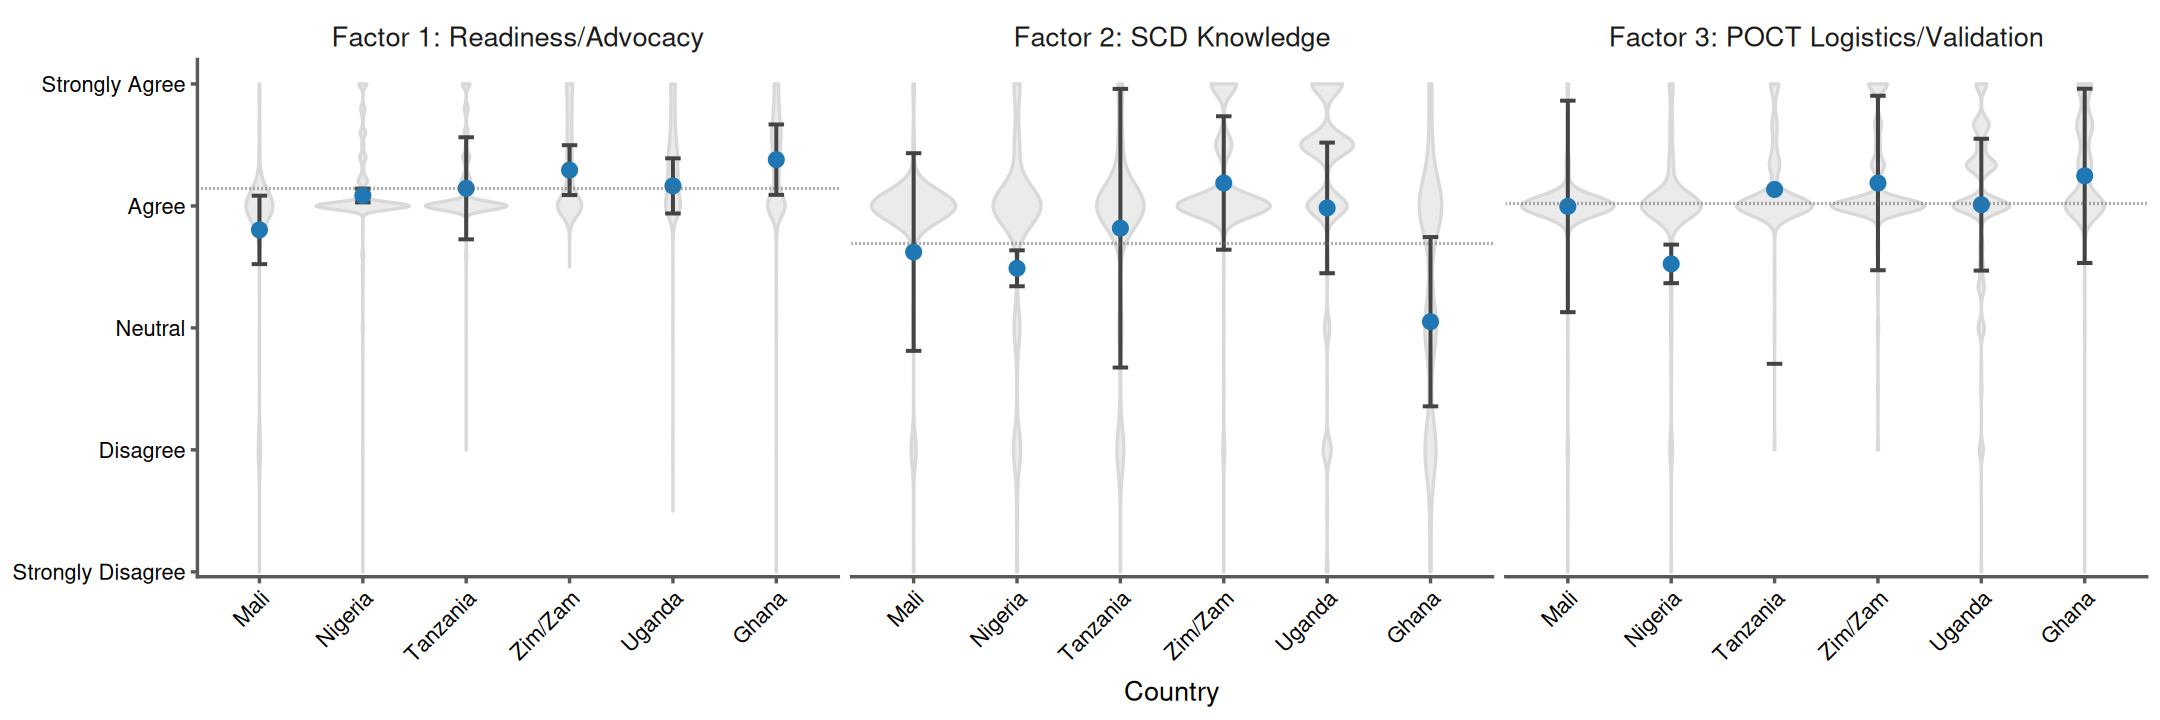

In [178]:
options(repr.plot.width = 18, repr.plot.height = 6)

df_base <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    facility = interaction(country, facility_id, drop = TRUE),
    F1 = suppressWarnings(as.numeric(F1_readiness)),
    F2 = suppressWarnings(as.numeric(F2_knowledge)),
    F3 = suppressWarnings(as.numeric(F3_poct))
  ) %>%
  filter(!is.na(country), !is.na(facility)) %>%
  mutate(
    country  = factor(country),
    facility = factor(facility)
  )

likert_labs <- c(
  "1" = "Strongly Disagree",
  "2" = "Disagree",
  "3" = "Neutral",
  "4" = "Agree",
  "5" = "Strongly Agree"
)

fit_and_emm <- function(dat, y, y_label){
  d <- dat %>%
    filter(is.finite(.data[[y]]), .data[[y]] >= 1, .data[[y]] <= 5)

  fit <- nlme::lme(
    fixed   = as.formula(paste(y, "~ country")),
    random  = ~ 1 | facility,
    data    = d,
    method  = "REML",
    na.action = na.omit
  )

  emm <- as.data.frame(emmeans::emmeans(fit, "country")) %>%
    rename(mean = emmean, lower = lower.CL, upper = upper.CL) %>%
    mutate(factor = y_label)

  raw <- d %>%
    select(country, value = all_of(y)) %>%
    mutate(factor = y_label)

  list(emm = emm, raw = raw)
}

r1 <- fit_and_emm(df_base, "F1", "Factor 1: Readiness/Advocacy")
r2 <- fit_and_emm(df_base, "F2", "Factor 2: SCD Knowledge")
r3 <- fit_and_emm(df_base, "F3", "Factor 3: POCT Logistics/Validation")

emm_all <- bind_rows(r1$emm, r2$emm, r3$emm)
raw_all <- bind_rows(r1$raw, r2$raw, r3$raw)

emm_all <- emm_all %>%
  group_by(factor) %>%
  mutate(country = fct_reorder(country, mean)) %>%
  ungroup()

raw_all <- raw_all %>%
  left_join(emm_all %>% select(country, factor) %>% distinct(),
            by = c("country","factor")) %>%
  group_by(factor) %>%
  mutate(country = fct_reorder(country, value, .fun = median, .desc = FALSE)) %>%
  ungroup()

grand_means <- emm_all %>%
  group_by(factor) %>%
  summarise(gm = mean(mean), .groups = "drop")

base_theme <- theme_classic(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 10)),
    axis.ticks   = element_line(color = "grey35"),
    axis.line.x  = element_line(color = "grey35"),
    axis.text.x  = element_text(size = 13, angle = 45, hjust = 1, vjust = 1),
    axis.line.y  = element_line(color = "grey35"),
    plot.title   = element_text(hjust = 0.5, face = "bold", size = 18),
    legend.position = "none",
    strip.background = element_blank(),      
    strip.text = element_text(size = 16)  
  )

p <- ggplot() +
  geom_violin(
    data = raw_all,
    aes(x = country, y = value),
    fill = "grey92", color = "grey85", width = 0.9, trim = TRUE
  ) +
  geom_errorbar(
    data = emm_all,
    aes(x = country, ymin = lower, ymax = upper),
    width = 0.15, size = 0.85, color = "#444444"
  ) +
  geom_point(
    data = emm_all,
    aes(x = country, y = mean),
    size = 3.4, color = "#1f78b4"
  ) +
  geom_hline(
    data = grand_means,
    aes(yintercept = gm), linetype = 3, color = "grey40"
  ) +
  scale_y_continuous(
    limits = c(1, 5),
    breaks = 1:5,
    labels = likert_labs,
    expand = expansion(mult = c(0.01, 0.05))
  ) +
  labs(x = "Country", y = NULL) +
  facet_wrap(~ factor, nrow = 1, scales = "free_x") +
  base_theme

p

out_dir <- "figures/analysis"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

ggsave(file.path(out_dir, "factor_means_by_country.png"),
       plot = p, width = 16, height = 6, units = "in",
       dpi = 600, bg = "white")

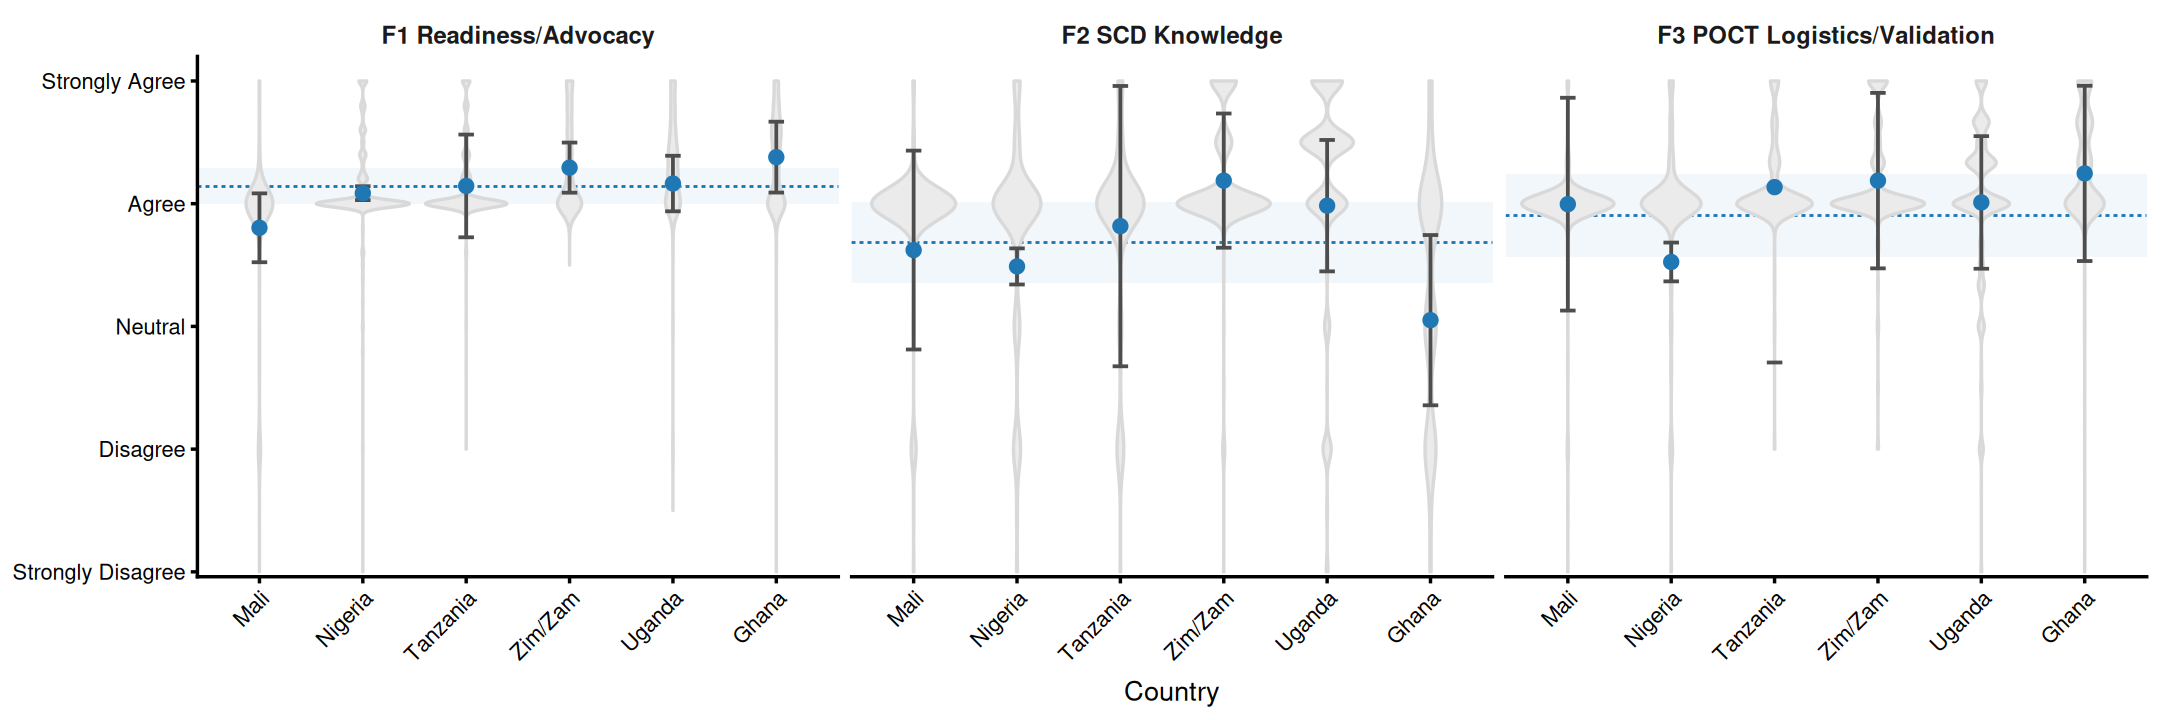

In [180]:
options(repr.plot.width = 18, repr.plot.height = 6)

df_base <- df_questionnaire %>%
  mutate(
    country = case_when(
      tolower(country) %in% c("zimbabwe/zambia","zim_zam","zim/zam","zim zam") ~ "Zim/Zam",
      TRUE ~ as.character(country)
    ),
    facility = interaction(country, facility_id, drop = TRUE),
    F1 = suppressWarnings(as.numeric(F1_readiness)),
    F2 = suppressWarnings(as.numeric(F2_knowledge)),
    F3 = suppressWarnings(as.numeric(F3_poct))
  ) %>%
  filter(!is.na(country), !is.na(facility)) %>%
  mutate(country = factor(country),
         facility = factor(facility))

fit_and_emm <- function(dat, y, y_label){
  d <- dat %>% filter(is.finite(.data[[y]]), .data[[y]] >= 1, .data[[y]] <= 5)

  fit <- nlme::lme(
    fixed   = as.formula(paste(y, "~ country")),
    random  = ~ 1 | facility,
    data    = d,
    method  = "REML",
    na.action = na.omit
  )

  emm <- as.data.frame(emmeans::emmeans(fit, "country")) %>%
    rename(mean = emmean, lower = lower.CL, upper = upper.CL) %>%
    mutate(factor = y_label)

  raw <- d %>%
    select(country, value = all_of(y)) %>%
    mutate(factor = y_label)

  list(emm = emm, raw = raw)
}

r1 <- fit_and_emm(df_base, "F1", "F1 Readiness/Advocacy")
r2 <- fit_and_emm(df_base, "F2", "F2 SCD Knowledge")
r3 <- fit_and_emm(df_base, "F3", "F3 POCT Logistics/Validation")

emm_all <- bind_rows(r1$emm, r2$emm, r3$emm)
raw_all <- bind_rows(r1$raw, r2$raw, r3$raw)

emm_all <- emm_all %>% group_by(factor) %>% mutate(country = fct_reorder(country, mean)) %>% ungroup()
raw_all <- raw_all %>%
  left_join(emm_all %>% select(country, factor) %>% distinct(), by = c("country","factor")) %>%
  group_by(factor) %>% mutate(country = fct_reorder(country, value, .fun = median)) %>% ungroup()

overall_null <- function(dat, y, y_label){
  d <- dat %>% filter(is.finite(.data[[y]]), .data[[y]] >= 1, .data[[y]] <= 5)
  fit0 <- nlme::lme(
    fixed   = as.formula(paste(y, "~ 1")),
    random  = ~ 1 | country/facility,
    data    = d,
    method  = "REML",
    na.action = na.omit
  )
  b0 <- fixed.effects(fit0)[1]
  se <- sqrt(vcov(fit0)[1,1])
  tibble(factor = y_label, gm = b0, lwr = b0 - 1.96*se, upr = b0 + 1.96*se)
}

overall_df <- bind_rows(
  overall_null(df_base, "F1", "F1 Readiness/Advocacy"),
  overall_null(df_base, "F2", "F2 SCD Knowledge"),
  overall_null(df_base, "F3", "F3 POCT Logistics/Validation")
)

likert_breaks  <- 1:5
likert_labels  <- c("Strongly Disagree","Disagree","Neutral","Agree","Strongly Agree")

base_theme <- theme_classic(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 10)),
    axis.text.x  = element_text(size = 13, angle = 45, hjust = 1, vjust = 1),
    strip.background = element_blank(),        
    strip.text = element_text(size = 14, face = "bold"),
    legend.position = "none"
  )

p <- ggplot() +
  geom_rect(
    data = overall_df,
    aes(ymin = lwr, ymax = upr, xmin = -Inf, xmax = Inf),
    inherit.aes = FALSE, fill = "#1f78b4", alpha = 0.06
  ) +
  geom_hline(
    data = overall_df,
    aes(yintercept = gm),
    linetype = "dashed", color = "#1f78b4", linewidth = 0.6
  ) +
  geom_violin(
    data = raw_all,
    aes(x = country, y = value),
    fill = "grey92", color = "grey85", width = 0.9, trim = TRUE
  ) +
  geom_errorbar(
    data = emm_all,
    aes(x = country, ymin = lower, ymax = upper),
    width = 0.15, linewidth = 0.8, color = "grey30"
  ) +
  geom_point(
    data = emm_all,
    aes(x = country, y = mean),
    size = 3.2, color = "#1f78b4"
  ) +
  scale_y_continuous(
    breaks = likert_breaks, labels = likert_labels,
    limits = c(1, 5), expand = expansion(mult = c(0.01, 0.05))
  ) +
  labs(x = "Country", y = NULL) +
  facet_wrap(~ factor, nrow = 1, scales = "free_x") +
  base_theme

p

# dir.create("figures/analysis", showWarnings = FALSE, recursive = TRUE)
ggsave("figures/analysis/factor_means_by_country_with_overall.png",
       plot = p, width = 16, height = 6, units = "in", dpi = 600, bg = "white")

In [174]:
extract_vc_nlme <- function(fit) {
  vc <- nlme::VarCorr(fit)
  vc_df <- tryCatch({
    data.frame(
      grp = rownames(vc),
      Variance = suppressWarnings(as.numeric(vc[, "Variance"])),
      StdDev  = suppressWarnings(as.numeric(vc[, "StdDev"])),
      row.names = NULL,
      check.names = FALSE
    )
  }, error = function(e) NULL)
  if (is.null(vc_df)) {
    return(list(
      v_country = 0,
      v_fac     = 0,
      v_res     = as.numeric(nlme::sigma(fit))^2
    ))
  }

  rns <- vc_df$grp
  v_res <- vc_df$Variance[grepl("Residual", rns, ignore.case = TRUE)]
  v_res <- ifelse(length(v_res) == 0, as.numeric(nlme::sigma(fit))^2, v_res[1])
  v_country <- NA_real_
  v_fac     <- NA_real_

  for (i in seq_along(rns)) {
    if (grepl("country", rns[i], ignore.case = TRUE) && i + 1 <= length(rns)) {
      cand <- vc_df$Variance[i + 1]
      if (is.finite(cand)) v_country <- cand
    }
    if (grepl("facility", rns[i], ignore.case = TRUE) && i + 1 <= length(rns)) {
      cand <- vc_df$Variance[i + 1]
      if (is.finite(cand)) v_fac <- cand
    }
  }

  if (!is.finite(v_country)) {
    idx <- which(grepl("\\(Intercept\\)", rns) & !grepl("Residual", rns, ignore.case = TRUE))
    if (length(idx) >= 1) v_country <- vc_df$Variance[idx[1]]
  }
  if (!is.finite(v_fac) && length(idx) >= 2) {
    v_fac <- vc_df$Variance[idx[2]]
  }

  v_country <- ifelse(is.finite(v_country), v_country, 0)
  v_fac     <- ifelse(is.finite(v_fac),     v_fac,     0)

  list(v_country = v_country, v_fac = v_fac, v_res = v_res)
}

overall_row <- function(dat, y, label){
  d <- dat %>% dplyr::filter(is.finite(.data[[y]]), .data[[y]] >= 1, .data[[y]] <= 5)

  fit <- nlme::lme(
    fixed   = as.formula(paste(y, "~ 1")),       
    random  = ~ 1 | country/facility,           
    data    = d,
    method  = "REML",
    na.action = na.omit
  )

  mu  <- fixed.effects(fit)[1]
  se  <- sqrt(vcov(fit)[1,1])
  lwr <- mu - 1.96 * se
  upr <- mu + 1.96 * se

  vc <- extract_vc_nlme(fit)
  v_country <- vc$v_country; v_fac <- vc$v_fac; v_res <- vc$v_res
  v_tot <- v_country + v_fac + v_res
  icc_country  <- if (v_tot > 0) v_country / v_tot else 0
  icc_facility <- if (v_tot > 0) v_fac     / v_tot else 0

  tibble::tibble(
    factor       = label,
    n            = nrow(d),
    countries    = nlevels(d$country),
    facilities   = nlevels(d$facility),
    mean         = round(mu,   2),
    lower        = round(lwr,  2),
    upper        = round(upr,  2),
    sd_country   = round(sqrt(max(v_country,0)), 3),
    sd_facility  = round(sqrt(max(v_fac,0)),     3),
    sd_resid     = round(sqrt(max(v_res,0)),     3),
    icc_country  = round(icc_country,  3),
    icc_facility = round(icc_facility, 3)
  )
}

overall_tbl <- dplyr::bind_rows(
  overall_row(df_base, "F1", "Factor 1: Readiness/Advocacy"),
  overall_row(df_base, "F2", "Factor 2: SCD Knowledge"),
  overall_row(df_base, "F3", "Factor 3: POCT Logistics/Validation")
)
                    
writexl::write_xlsx(list(overall_summary = overall_tbl),
                    "figures/analysis/overall_factor_summary.xlsx")

In [175]:
overall_tbl

factor,n,countries,facilities,mean,lower,upper,sd_country,sd_facility,sd_resid,icc_country,icc_facility
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Factor 1: Readiness/Advocacy,7069,6,133,4.14,4.00,4.29,0.134,0.212,0.378,0.088,0.218
Factor 2: SCD Knowledge,6478,6,133,3.68,3.35,4.01,0.290,0.565,0.730,0.090,0.340
Factor 3: POCT Logistics/Validation,6830,6,133,3.90,3.57,4.24,0.275,0.708,0.449,0.097,0.643


In [176]:
overall_out <- overall_tbl %>%
  dplyr::rename(
    `Factor` = factor, `N` = n, `#Countries` = countries, `#Facilities` = facilities,
    `Mean` = mean, `Lower 95%` = lower, `Upper 95%` = upper,
    `SD (Country)` = sd_country, `SD (Facility)` = sd_facility, `SD (Residual)` = sd_resid,
    `ICC (Country)` = icc_country, `ICC (Facility)` = icc_facility
  ) %>%
  dplyr::mutate(dplyr::across(where(is.numeric), ~round(.x, 3)))

overall_out

suppressWarnings(suppressMessages(library(writexl)))
dir.create("figures/analysis", recursive = TRUE, showWarnings = FALSE)
writexl::write_xlsx(list(`Consortium factor summary` = overall_out),
                    "figures/analysis/overall_factor_summary.xlsx")

Factor,N,#Countries,#Facilities,Mean,Lower 95%,Upper 95%,SD (Country),SD (Facility),SD (Residual),ICC (Country),ICC (Facility)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Factor 1: Readiness/Advocacy,7069,6,133,4.14,4.00,4.29,0.134,0.212,0.378,0.088,0.218
Factor 2: SCD Knowledge,6478,6,133,3.68,3.35,4.01,0.290,0.565,0.730,0.090,0.340
Factor 3: POCT Logistics/Validation,6830,6,133,3.90,3.57,4.24,0.275,0.708,0.449,0.097,0.643


`height` was translated to `width`.
`height` was translated to `width`.


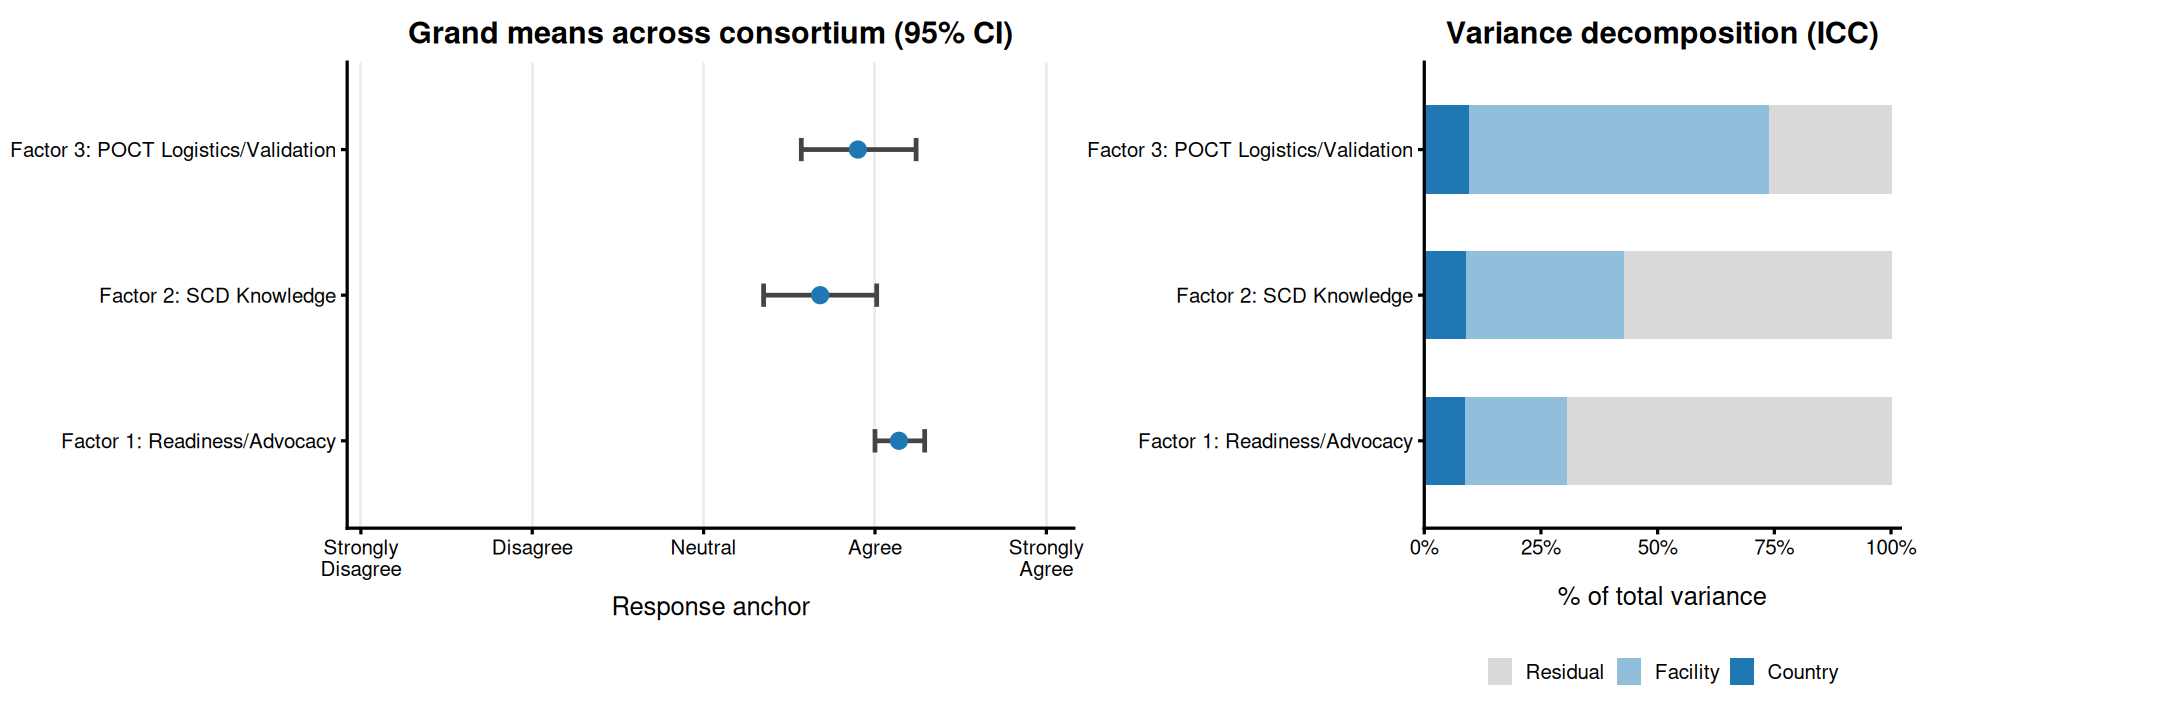

In [182]:
options(repr.plot.width = 18, repr.plot.height = 6)

plot_tbl <- overall_tbl %>%
  mutate(factor = factor(factor, levels = factor))

likert_breaks  <- 1:5
likert_labels  <- c("Strongly\nDisagree","Disagree","Neutral","Agree","Strongly\nAgree")

p_forest <- ggplot(plot_tbl, aes(x = mean, y = factor)) +
  geom_vline(xintercept = likert_breaks, color = "grey92", linewidth = 0.6) +
  geom_errorbarh(aes(xmin = lower, xmax = upper), height = 0.16,
                 linewidth = 1, color = "#444444") +
  geom_point(size = 3.8, color = "#1f78b4") +
  scale_x_continuous(limits = c(1, 5), breaks = likert_breaks, labels = likert_labels,
                     expand = expansion(mult = c(0.02, 0.04))) +
  labs(title = "Grand means across consortium (95% CI)", x = "Response anchor", y = NULL) +
  theme_classic(base_size = 15) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 10))
  )

var_long <- plot_tbl %>%
  transmute(
    factor,
    Country  = icc_country,
    Facility = icc_facility,
    Residual = pmax(0, 1 - icc_country - icc_facility)
  ) %>%
  pivot_longer(-factor, names_to = "Component", values_to = "prop") %>%
  mutate(
    Component = factor(Component, levels = c("Residual", "Facility", "Country"))
  )

p_var <- ggplot(var_long, aes(y = factor, x = prop * 100, fill = Component)) +
  geom_col(width = 0.6) +
  scale_x_continuous(labels = function(x) paste0(x, "%"), limits = c(0, 100),
                     expand = expansion(mult = c(0, 0.02))) +
  scale_fill_manual(values = c(Residual = "#d9d9d9", Facility = "#91bfdb", Country = "#1f78b4")) +
  labs(title = "Variance decomposition (ICC)", x = "% of total variance", y = NULL, fill = NULL) +
  theme_classic(base_size = 15) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "bottom",
    legend.key.width = unit(16, "pt")
  )

final_plot <- p_forest | p_var + plot_layout(widths = c(2, 1))
final_plot

dir.create("figures/analysis", recursive = TRUE, showWarnings = FALSE)
ggsave("figures/analysis/overall_forest_and_variance.png",
       final_plot, width = 12, height = 5, dpi = 600, bg = "white")